# Multiclass IMV — Dry Bean

One-vs-rest IMV and the pairwise IMV matrix on the UCI Dry Bean dataset
(seven classes, 16 continuous morphological features).

Like Car Evaluation, this has **no counterpart in the original notebooks**; the
published panel was hardcoded. These are new results.

**Pipeline**: download from UCI → standardise → 10 seeds × 3 estimators →
aggregate.

Full documentation: `documentation/examples/multi_imv/dry_bean.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "multi_imv_dry_bean"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)
FIGURES = Path(os.environ.get(
    "IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"
))
FIGURES.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from empirical.plotter.figure_utils import (
    COLORMAP, configure_plotting, spectral_colors,
    save_publication_figure as save_figure,
)
configure_plotting()
FORCE_RECOMPUTE = os.environ.get("IMV_FORCE_RECOMPUTE", "0").strip().lower() in {
    "1", "true", "yes",
}

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imvpy
from imvpy import MulticlassIMV

IMVPY_SOURCE = Path(imvpy.__file__).resolve().parent
print(f"imvpy {imvpy.__version__} from {relative_path(IMVPY_SOURCE)}")


imvpy 1.2.0 from ../../../../../../../../anaconda3/lib/python3.12/site-packages/imvpy


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "dry_bean", "Dry Bean"
raw = fetch_ucirepo(id=602)
frame = raw.data.features.copy()
frame["target_raw"] = raw.data.targets.iloc[:, 0].astype(str).str.strip()
print(frame.shape); print(frame["target_raw"].value_counts().to_dict())
frame.head()

(13611, 17)
{'DERMASON': 3546, 'SIRA': 2636, 'SEKER': 2027, 'HOROZ': 1928, 'CALI': 1630, 'BARBUNYA': 1322, 'BOMBAY': 522}


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,target_raw
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 2. Preprocess

In [3]:
CLASS_NAMES = sorted(frame["target_raw"].unique())
frame["target"] = frame["target_raw"].map({n: i for i, n in enumerate(CLASS_NAMES)})
FEATURES = [c for c in frame.columns if c not in ("target", "target_raw")]
frame[FEATURES] = frame[FEATURES].apply(pd.to_numeric, errors="coerce")
# Continuous features on wildly different scales; standardise so logistic
# regression converges rather than scoring a half-optimised model.
frame[FEATURES] = StandardScaler().fit_transform(frame[FEATURES])
data = frame[FEATURES + ["target"]].dropna()
data["target"] = data["target"].astype(int)
print(data.shape, len(FEATURES), "features,", len(CLASS_NAMES), "classes")
data.head()

(13611, 17) 16 features, 7 classes


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,target
0,-0.840749,-1.143319,-1.306598,-0.631153,-1.565053,-2.185720,-0.841451,-1.063341,0.289087,0.367614,1.423867,1.839116,0.680786,2.402173,1.925723,0.838371,5
1,-0.829188,-1.013924,-1.395911,-0.434445,-1.969784,-3.686040,-0.826102,-1.044217,0.697477,-0.462907,0.231054,2.495449,0.367967,3.100894,2.689702,0.771138,5
2,-0.807157,-1.078829,-1.252357,-0.585735,-1.514291,-2.045336,-0.808704,-1.008084,0.578195,0.518417,1.252865,1.764843,0.603129,2.235091,1.841356,0.916755,5
3,-0.785741,-0.977215,-1.278825,-0.439290,-1.741618,-2.742211,-0.773975,-0.973337,0.671260,-2.241767,0.515049,2.081715,0.401718,2.515075,2.204250,-0.197985,5
4,-0.781239,-1.097384,-1.380471,-0.266663,-2.117993,-4.535028,-0.784286,-0.966080,0.476020,0.804772,1.874992,2.765330,0.118268,3.270983,3.013462,0.939640,5


## 3. Estimators

In [4]:
from joblib import Parallel, delayed, parallel_config
from tqdm.auto import tqdm

# Seed/model evaluations are independent. Keep each estimator single-threaded so
# outer process parallelism does not create nested CPU pools.
MODEL_PARAMETERS = {
    "logistic_regression": {"max_iter": 5000},
    "xgboost": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                "verbosity": 0, "tree_method": "hist", "n_jobs": 1},
    "lightgbm": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                 "verbose": -1, "n_jobs": 1},
}
MODEL_NAMES = tuple(MODEL_PARAMETERS)
CPU_COUNT = (len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity")
             else (os.cpu_count() or 1))
DEFAULT_OUTER_JOBS = min(15, max(1, CPU_COUNT - 1))
OUTER_N_JOBS = int(os.environ.get("IMV_N_JOBS", DEFAULT_OUTER_JOBS))
if OUTER_N_JOBS < 1:
    raise ValueError("IMV_N_JOBS must be a positive integer")
OUTER_N_JOBS = min(OUTER_N_JOBS, len(SEEDS) * len(MODEL_NAMES))

def model_factories(seed):
    """Three estimator families with fixed parameters across every seed."""
    return {
        "logistic_regression": lambda: LogisticRegression(
            random_state=seed, **MODEL_PARAMETERS["logistic_regression"]),
        "xgboost": lambda: XGBClassifier(
            random_state=seed, **MODEL_PARAMETERS["xgboost"]),
        "lightgbm": lambda: LGBMClassifier(
            random_state=seed, **MODEL_PARAMETERS["lightgbm"]),
    }

print(f"outer workers: {OUTER_N_JOBS}; estimator workers per task: 1")


outer workers: 15; estimator workers per task: 1


## 4. One-vs-rest and pairwise IMV over ten seeds

Stratified folds are used so no fold can omit a class; the evaluator passes `model.classes_` through, so probability columns are matched to labels rather than to fold position.

Seed/model jobs run in parallel and are checkpointed individually. Aggregation is restored to the original seed/model order, so scheduling does not change the reported results.

In [5]:
import hashlib, json
from time import perf_counter

frame = data.reset_index(drop=True)
data_fingerprint = hashlib.sha256(
    pd.util.hash_pandas_object(frame[FEATURES + ["target"]], index=True)
    .to_numpy().tobytes()
).hexdigest()
run_config = {
    "class_names": [str(name) for name in CLASS_NAMES],
    "data_sha256": data_fingerprint,
    "features": FEATURES,
    "imvpy_version": imvpy.__version__,
    "model_parameters": MODEL_PARAMETERS,
    "n_splits": N_SPLITS,
    "stratified": True,
}
RUN_SIGNATURE = hashlib.sha256(
    json.dumps(run_config, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()[:12]
CHECKPOINTS = RESULTS / "checkpoints" / RUN_SIGNATURE
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
EXPECTED_CLASSES = tuple(sorted(frame["target"].unique().tolist()))
OVA_COLUMNS = ["seed", "model", "class", "one_vs_rest_imv"]

def checkpoint_paths(seed, model_name):
    stem = f"seed_{seed}_{model_name}"
    return CHECKPOINTS / f"{stem}_ova.csv", CHECKPOINTS / f"{stem}_matrix.csv"

def write_csv_atomic(table, path, *, index=False):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=index)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def read_checkpoint(seed, model_name):
    ova_path, matrix_path = checkpoint_paths(seed, model_name)
    ova_part = pd.read_csv(ova_path)
    matrix = pd.read_csv(matrix_path, index_col=0)
    expected_text = [str(value) for value in EXPECTED_CLASSES]
    valid = (
        list(ova_part.columns) == OVA_COLUMNS,
        len(ova_part) == len(EXPECTED_CLASSES),
        ova_part["seed"].eq(seed).all(),
        ova_part["model"].eq(model_name).all(),
        [str(value) for value in ova_part["class"]] == expected_text,
        matrix.shape == (len(EXPECTED_CLASSES), len(EXPECTED_CLASSES)),
        [str(value) for value in matrix.index] == expected_text,
        [str(value) for value in matrix.columns] == expected_text,
        np.isfinite(ova_part["one_vs_rest_imv"].to_numpy(dtype=float)).all(),
        np.isfinite(matrix.to_numpy(dtype=float)).all(),
    )
    if not all(valid):
        raise ValueError(f"invalid checkpoint: {ova_path.name}, {matrix_path.name}")
    ova_part["class"] = list(EXPECTED_CLASSES)
    matrix.index = EXPECTED_CLASSES
    matrix.columns = EXPECTED_CLASSES
    return {"seed": seed, "model": model_name, "ova": ova_part,
            "matrix": matrix, "elapsed": None}

def evaluate_seed_model(seed, model_name):
    started = perf_counter()
    evaluator = MulticlassIMV(
        frame, "target", model_factories(seed)[model_name], n_splits=N_SPLITS,
        optional_explanatory_variables=FEATURES,
        random_state=seed, stratified=True,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=("X does not have valid feature names, but "
                     "LGBMClassifier was fitted with feature names"),
            category=UserWarning,
        )
        _, ova_mean = evaluator.k_fold_one_vs_all()
        _, matrix_mean = evaluator.k_fold_imv_matrix()
    ova_part = pd.DataFrame([
        {"seed": seed, "model": model_name, "class": label,
         "one_vs_rest_imv": value}
        for label, value in zip(matrix_mean.index, ova_mean)
    ], columns=OVA_COLUMNS)
    ova_path, matrix_path = checkpoint_paths(seed, model_name)
    write_csv_atomic(ova_part, ova_path)
    write_csv_atomic(matrix_mean, matrix_path, index=True)
    return {"seed": seed, "model": model_name, "ova": ova_part,
            "matrix": matrix_mean, "elapsed": perf_counter() - started}

jobs = [(seed, model_name) for seed in SEEDS for model_name in MODEL_NAMES]
job_results, pending = [], []
for seed, model_name in jobs:
    if FORCE_RECOMPUTE:
        pending.append((seed, model_name))
        continue
    try:
        job_results.append(read_checkpoint(seed, model_name))
    except (FileNotFoundError, OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        pending.append((seed, model_name))
        if not isinstance(error, FileNotFoundError):
            print(f"recomputing {model_name} seed {seed}: {error}")

cached = len(job_results)
mode = "fresh" if FORCE_RECOMPUTE else "resume"
print(f"{mode} mode; run {RUN_SIGNATURE}: {cached}/{len(jobs)} jobs restored; "
      f"running {len(pending)} with {OUTER_N_JOBS} workers")
if pending:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        stream = Parallel(
            n_jobs=OUTER_N_JOBS, return_as="generator_unordered",
            batch_size=1, pre_dispatch=OUTER_N_JOBS,
        )(delayed(evaluate_seed_model)(seed, model_name)
          for seed, model_name in pending)
        with tqdm(total=len(jobs), initial=cached, desc="seed/model evaluations",
                  unit="job") as progress:
            for result in stream:
                job_results.append(result)
                progress.set_postfix_str(
                    f"{result['model']} seed {result['seed']} {result['elapsed']:.1f}s")
                progress.update()

if len(job_results) != len(jobs):
    raise RuntimeError(f"expected {len(jobs)} results, found {len(job_results)}")
seed_order = {seed: index for index, seed in enumerate(SEEDS)}
model_order = {name: index for index, name in enumerate(MODEL_NAMES)}
job_results.sort(key=lambda result: (
    seed_order[result["seed"]], model_order[result["model"]]
))

ova = pd.concat([result["ova"] for result in job_results], ignore_index=True)
matrices = {name: [] for name in MODEL_NAMES}
for result in job_results:
    matrices[result["model"]].append(result["matrix"])

write_csv_atomic(ova, RESULTS / f"{DATASET}_one_vs_rest_by_seed.csv")
mean_matrices = {name: sum(matrices[name]) / len(matrices[name])
                 for name in MODEL_NAMES}
for name, matrix in mean_matrices.items():
    write_csv_atomic(matrix, RESULTS / f"{DATASET}_pairwise_imv_{name}.csv", index=True)
ova.groupby(["model", "class"])["one_vs_rest_imv"].agg(["mean", "std"]).reset_index()


fresh mode; run 483275795a9f: 0/30 jobs restored; running 30 with 15 workers


seed/model evaluations:   0%|          | 0/30 [00:00<?, ?job/s]

,model,class,mean,std
0,lightgbm,0,0.101238,0.000092
1,lightgbm,1,0.039725,0.000087
2,lightgbm,2,0.128976,0.000253
3,lightgbm,3,0.326932,0.000243
4,lightgbm,4,0.157517,0.000144
5,lightgbm,5,0.166722,0.000217
6,lightgbm,6,0.209328,0.000206
7,logistic_regression,0,0.100399,0.000095
8,logistic_regression,1,0.039839,0.000002
9,logistic_regression,2,0.128069,0.000038


## 5. One-vs-rest figure

Each bar is the mean over the seeds; the error bar is the spread across seeds, which describes stability and is **not** a confidence interval.

One-vs-rest and pairwise IMV are **not on the same scale** and must not be read against each other. The one-vs-rest null model already knows the class base rate, so it starts above chance; pairwise renormalisation leaves its null at the 0.5 chance floor. Identical predictive power therefore reads lower under one-vs-rest.

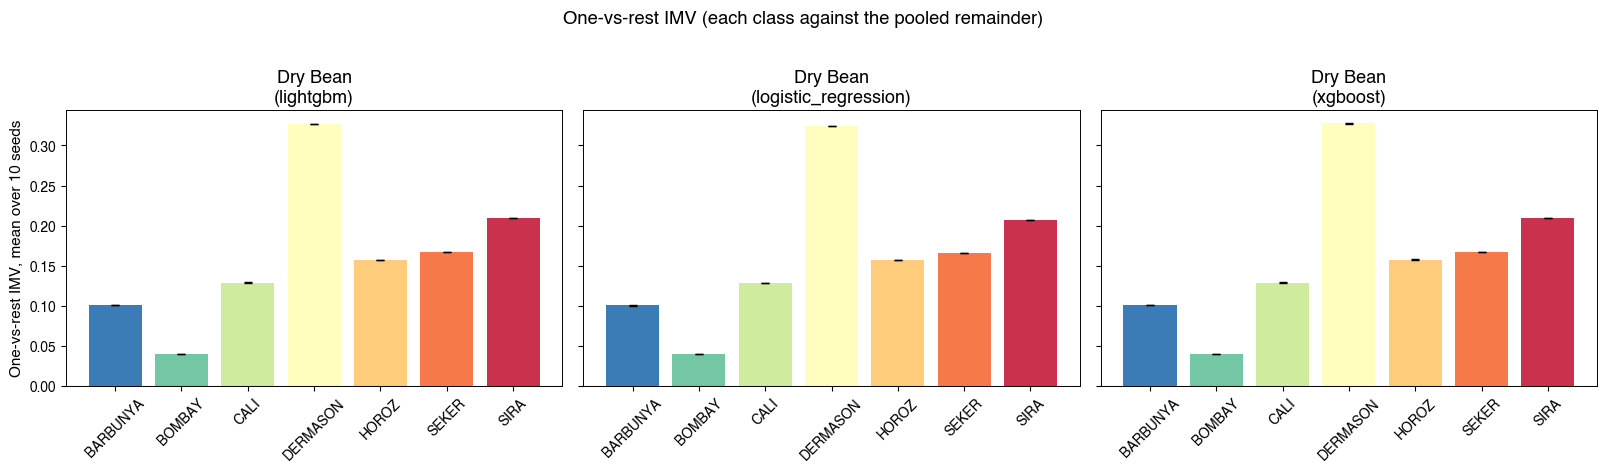

{'pdf': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_dry_bean__one_vs_rest_imv.pdf'}

In [2]:
ova_summary = (ova.groupby(["model", "class"])["one_vs_rest_imv"]
               .agg(["mean", "std"]).reset_index())
models = list(ova_summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5.4 * len(models), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = ova_summary[ova_summary.model == name].sort_values("class")
    ax.bar([CLASS_NAMES[int(c)] for c in part["class"]], part["mean"],
           yerr=part["std"].fillna(0), capsize=3,
           color=spectral_colors(len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"One-vs-rest IMV, mean over {len(SEEDS)} seeds")
fig.suptitle("One-vs-rest IMV (each class against the pooled remainder)", y=1.02)
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / "multi_imv_dry_bean__one_vs_rest_imv"
         ).items()}
plt.show()
paths

## 6. Pairwise figure

The pairwise matrix is **symmetric by construction** — `ll` is invariant under `(y,p) -> (1-y,1-p)` and pairwise renormalisation gives `p_j = 1 - p_i`. Unlike the ablation matrix it carries no directional information.

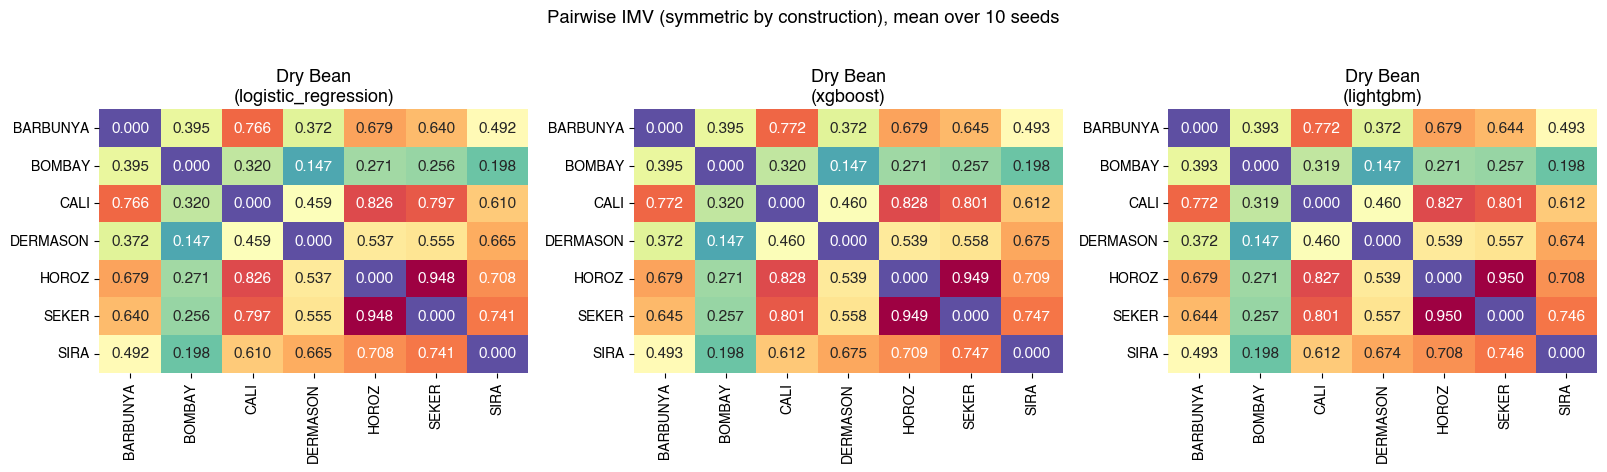

{'pdf': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/multi_imv_dry_bean__pairwise_imv.pdf'}

In [3]:
fig, axes = plt.subplots(1, len(mean_matrices), figsize=(5.4 * len(mean_matrices), 4.6))
axes = np.atleast_1d(axes)
for ax, (name, matrix) in zip(axes, mean_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt=".3f", cmap=COLORMAP, cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{TITLE}\n({name})")
fig.suptitle("Pairwise IMV (symmetric by construction), mean over "
             f"{len(SEEDS)} seeds", y=1.02)
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / "multi_imv_dry_bean__pairwise_imv"
         ).items()}
plt.show()
paths


## 7. Per-class classification metrics

The sections above say how much the features add over the null model. This one says how the same fits behave as a classifier, so the two can be read side by side for every class.

The IMV evaluator scores its predictions without returning them, so the folds are replayed here with the same splitter, the same seed and the same estimator parameters as section 4 — the fits, and therefore the predicted probabilities, are the ones the one-vs-rest IMV was computed from. Every row is predicted exactly once, out of fold, and the metrics read that pooled vector; jobs are checkpointed under the same run signature.

Each class is read **one-vs-rest**, matching the IMV column beside it: `accuracy` is the accuracy of that binary problem, not the share of the class recovered. On an imbalanced class the two diverge sharply — a class holding 4% of the rows scores about 96% one-vs-rest accuracy while never being predicted at all, which is exactly what its `recall` of 0 reports. Read them together, and note this differs from the published table, where the per-class accuracy column repeats precision.

Global metrics are support-weighted averages over the same out-of-fold vector, so a rare class cannot outweigh a common one.

Every number is a mean over the ten seeds; the value after `±` is the spread across seeds, which describes stability and is **not** a confidence interval. The tables are written both to the artefact cache and to `output/examples/multi_imv/`.

In [8]:
from sklearn.metrics import (accuracy_score, brier_score_loss, cohen_kappa_score,
                             f1_score, hamming_loss, jaccard_score, log_loss,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold

# The IMV evaluator scores the enhanced model but does not hand its predictions
# back, so the folds are replayed here: same splitter, same seed, same estimator
# parameters as `evaluate_seed_model`, hence the same fits. Every row is
# predicted exactly once, out of fold, and the metrics below read that vector.
METRICS_OUTPUT = PROJECT_ROOT / "output" / "examples" / "multi_imv"
METRICS_OUTPUT.mkdir(parents=True, exist_ok=True)

CLASS_METRIC_COLUMNS = ["seed", "model", "class", "brier_loss", "accuracy",
                        "precision", "recall"]
GLOBAL_METRIC_COLUMNS = ["seed", "model", "f1_weighted", "roc_auc_ovr_weighted",
                         "log_loss", "hamming_loss", "cohens_kappa",
                         "jaccard_weighted"]

def metric_checkpoint_paths(seed, model_name):
    stem = f"seed_{seed}_{model_name}"
    return (CHECKPOINTS / f"{stem}_class_metrics.csv",
            CHECKPOINTS / f"{stem}_global_metrics.csv")

def out_of_fold_probabilities(seed, model_name):
    """One out-of-fold probability row per observation, columns in class order."""
    X = frame[FEATURES]
    y = frame["target"].to_numpy()
    column_of = {label: index for index, label in enumerate(EXPECTED_CLASSES)}
    probabilities = np.full((len(frame), len(EXPECTED_CLASSES)), np.nan)
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for train_index, test_index in splitter.split(frame, frame["target"]):
        model = model_factories(seed)[model_name]()
        model.fit(X.iloc[train_index], frame["target"].iloc[train_index])
        fold_probabilities = model.predict_proba(X.iloc[test_index])
        # Columns are matched through `model.classes_`, never by fold position.
        for position, label in enumerate(model.classes_):
            probabilities[test_index, column_of[label]] = fold_probabilities[:, position]
    if not np.isfinite(probabilities).all():
        raise RuntimeError(f"{model_name} seed {seed}: rows left unpredicted")
    # The boosted models hand back float32 softmax output, whose rows sum to one
    # only to about 1e-7. Renormalise so the log loss below is read off a proper
    # distribution rather than one sklearn flags as unnormalised.
    return y, probabilities / probabilities.sum(axis=1, keepdims=True)

def classification_metrics(seed, model_name):
    """Per-class and global metrics for one seed/model, on its out-of-fold vector."""
    started = perf_counter()
    y, probabilities = out_of_fold_probabilities(seed, model_name)
    predicted = np.asarray(EXPECTED_CLASSES)[probabilities.argmax(axis=1)]
    class_rows = []
    for index, label in enumerate(EXPECTED_CLASSES):
        # Per class the problem is read one-vs-rest, exactly as the IMV column
        # next to it is: this class against the pooled remainder. Accuracy is
        # therefore that binary accuracy, not the share of the class recovered.
        actual = (y == label).astype(int)
        flagged = (predicted == label).astype(int)
        class_rows.append({
            "seed": seed, "model": model_name, "class": label,
            "brier_loss": brier_score_loss(actual, probabilities[:, index]),
            "accuracy": accuracy_score(actual, flagged),
            "precision": precision_score(actual, flagged, zero_division=0),
            "recall": recall_score(actual, flagged, zero_division=0),
        })
    labels = list(EXPECTED_CLASSES)
    global_row = {
        "seed": seed, "model": model_name,
        # Support-weighted averages: the classes are imbalanced, and a macro
        # average would let a 65-row class outweigh a 1210-row one.
        "f1_weighted": f1_score(y, predicted, average="weighted", zero_division=0),
        "roc_auc_ovr_weighted": roc_auc_score(y, probabilities, labels=labels,
                                              multi_class="ovr", average="weighted"),
        "log_loss": log_loss(y, probabilities, labels=labels),
        "hamming_loss": hamming_loss(y, predicted),
        "cohens_kappa": cohen_kappa_score(y, predicted, labels=labels),
        "jaccard_weighted": jaccard_score(y, predicted, average="weighted",
                                          zero_division=0),
    }
    class_part = pd.DataFrame(class_rows, columns=CLASS_METRIC_COLUMNS)
    global_part = pd.DataFrame([global_row], columns=GLOBAL_METRIC_COLUMNS)
    class_path, global_path = metric_checkpoint_paths(seed, model_name)
    write_csv_atomic(class_part, class_path)
    write_csv_atomic(global_part, global_path)
    return {"seed": seed, "model": model_name, "class_metrics": class_part,
            "global_metrics": global_part, "elapsed": perf_counter() - started}

def read_metric_checkpoint(seed, model_name):
    class_path, global_path = metric_checkpoint_paths(seed, model_name)
    class_part = pd.read_csv(class_path)
    global_part = pd.read_csv(global_path)
    expected_text = [str(value) for value in EXPECTED_CLASSES]
    valid = (
        list(class_part.columns) == CLASS_METRIC_COLUMNS,
        list(global_part.columns) == GLOBAL_METRIC_COLUMNS,
        len(class_part) == len(EXPECTED_CLASSES),
        len(global_part) == 1,
        class_part["seed"].eq(seed).all(), class_part["model"].eq(model_name).all(),
        global_part["seed"].eq(seed).all(), global_part["model"].eq(model_name).all(),
        [str(value) for value in class_part["class"]] == expected_text,
        np.isfinite(class_part[CLASS_METRIC_COLUMNS[3:]].to_numpy(dtype=float)).all(),
        np.isfinite(global_part[GLOBAL_METRIC_COLUMNS[2:]].to_numpy(dtype=float)).all(),
    )
    if not all(valid):
        raise ValueError(f"invalid checkpoint: {class_path.name}, {global_path.name}")
    class_part["class"] = list(EXPECTED_CLASSES)
    return {"seed": seed, "model": model_name, "class_metrics": class_part,
            "global_metrics": global_part, "elapsed": None}

metric_results, metric_pending = [], []
for seed, model_name in jobs:
    if FORCE_RECOMPUTE:
        metric_pending.append((seed, model_name))
        continue
    try:
        metric_results.append(read_metric_checkpoint(seed, model_name))
    except (FileNotFoundError, OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        metric_pending.append((seed, model_name))
        if not isinstance(error, FileNotFoundError):
            print(f"recomputing metrics for {model_name} seed {seed}: {error}")

cached_metrics = len(metric_results)
print(f"{mode} mode; run {RUN_SIGNATURE}: {cached_metrics}/{len(jobs)} metric jobs "
      f"restored; running {len(metric_pending)} with {OUTER_N_JOBS} workers")
if metric_pending:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        stream = Parallel(
            n_jobs=OUTER_N_JOBS, return_as="generator_unordered",
            batch_size=1, pre_dispatch=OUTER_N_JOBS,
        )(delayed(classification_metrics)(seed, model_name)
          for seed, model_name in metric_pending)
        with tqdm(total=len(jobs), initial=cached_metrics, desc="metric evaluations",
                  unit="job") as progress:
            for result in stream:
                metric_results.append(result)
                progress.set_postfix_str(
                    f"{result['model']} seed {result['seed']} {result['elapsed']:.1f}s")
                progress.update()

if len(metric_results) != len(jobs):
    raise RuntimeError(f"expected {len(jobs)} metric results, found {len(metric_results)}")
metric_results.sort(key=lambda result: (
    seed_order[result["seed"]], model_order[result["model"]]
))

# The IMV column belongs in the same table as the metrics it is read against.
class_metrics = pd.concat([result["class_metrics"] for result in metric_results],
                          ignore_index=True)
class_metrics = (ova.rename(columns={"one_vs_rest_imv": "multi_imv"})
                 .merge(class_metrics, on=["seed", "model", "class"], how="inner"))
if len(class_metrics) != len(jobs) * len(EXPECTED_CLASSES):
    raise RuntimeError("IMV and metric rows did not align one to one")
global_metrics = pd.concat([result["global_metrics"] for result in metric_results],
                           ignore_index=True)

CLASS_METRIC_NAMES = ["multi_imv", "brier_loss", "accuracy", "precision", "recall"]
GLOBAL_METRIC_NAMES = GLOBAL_METRIC_COLUMNS[2:]

def summarise(table, keys, metric_names):
    """Mean and standard deviation across the seeds, one row per key."""
    summary = (table.groupby(keys)[metric_names]
               .agg(["mean", "std"]).reset_index())
    summary.columns = [column if not measure else f"{column}_{measure}"
                       for column, measure in summary.columns]
    return summary

class_summary = summarise(class_metrics, ["model", "class"], CLASS_METRIC_NAMES)
class_summary.insert(2, "class_name", [CLASS_NAMES[int(value)]
                                       for value in class_summary["class"]])
global_summary = summarise(global_metrics, ["model"], GLOBAL_METRIC_NAMES)

for table, name in ((class_metrics, "class_metrics_by_seed"),
                    (class_summary, "class_metrics_summary"),
                    (global_metrics, "global_metrics_by_seed"),
                    (global_summary, "global_metrics_summary")):
    write_csv_atomic(table, RESULTS / f"{DATASET}_{name}.csv")
    write_csv_atomic(table, METRICS_OUTPUT / f"{DATASET}_{name}.csv")
print(f"wrote four tables to {relative_path(METRICS_OUTPUT, start=PROJECT_ROOT)}/")
class_summary

resume mode; run 483275795a9f: 0/30 metric jobs restored; running 30 with 8 workers


metric evaluations:   0%|          | 0/30 [00:00<?, ?job/s]

wrote four tables to output/examples/multi_imv/


,model,class,class_name,multi_imv_mean,multi_imv_std,brier_loss_mean,brier_loss_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
0,lightgbm,0,BARBUNYA,0.101238,0.000092,0.009529,0.000165,0.987473,0.000400,0.946010,0.002144,0.923752,0.003379
1,lightgbm,1,BOMBAY,0.039725,0.000087,0.000186,0.000034,0.999809,0.000038,0.997320,0.000985,0.997701,0.000808
2,lightgbm,2,CALI,0.128976,0.000253,0.010180,0.000308,0.986687,0.000624,0.943605,0.003064,0.945337,0.002642
3,lightgbm,3,DERMASON,0.326932,0.000243,0.029330,0.000199,0.957623,0.000721,0.910227,0.001929,0.928962,0.001609
4,lightgbm,4,HOROZ,0.157517,0.000144,0.009685,0.000126,0.987562,0.000346,0.959223,0.002750,0.952697,0.001002
5,lightgbm,5,SEKER,0.166722,0.000217,0.011110,0.000184,0.985468,0.000307,0.953452,0.002097,0.948742,0.002248
6,lightgbm,6,SIRA,0.209328,0.000206,0.035033,0.000243,0.950452,0.000860,0.875219,0.003121,0.867906,0.002344
7,logistic_regression,0,BARBUNYA,0.100399,0.000095,0.010673,0.000106,0.985497,0.000278,0.942199,0.001266,0.906278,0.002240
8,logistic_regression,1,BOMBAY,0.039839,0.000002,0.000033,0.000008,0.999985,0.000031,1.000000,0.000000,0.999617,0.000808
9,logistic_regression,2,CALI,0.128069,0.000038,0.011128,0.000057,0.985277,0.000139,0.934108,0.000971,0.943620,0.000610


## 8. Metrics table

The published layout: one row per metric and estimator, one column per class. Rates, AUC-ROC, Cohen's kappa and Jaccard are shown as percentages; IMV, Brier loss and log loss keep their own scale.

In [9]:
# The published layout: one row per metric and estimator, one column per class,
# each cell a mean over the seeds with the spread across seeds after it.
MODEL_LABELS = {"logistic_regression": "LR", "xgboost": "XGB", "lightgbm": "LGBM"}
METRIC_LABELS = {"multi_imv": "Multi-IMV", "brier_loss": "Brier Loss",
                 "accuracy": "Accuracy", "precision": "Precision",
                 "recall": "Recall"}
GLOBAL_LABELS = {"f1_weighted": "F1 Score", "roc_auc_ovr_weighted": "AUC-ROC",
                 "log_loss": "Log Loss", "hamming_loss": "Hamming Loss",
                 "cohens_kappa": "Cohen's Kappa", "jaccard_weighted": "Jaccard"}
# Rates are shown as percentages; IMV, Brier and log loss keep their own scale.
PERCENT_METRICS = {"accuracy", "precision", "recall", "f1_weighted",
                   "roc_auc_ovr_weighted", "cohens_kappa", "jaccard_weighted"}

def format_cell(metric, mean, std):
    scale = 100 if metric in PERCENT_METRICS else 1
    return f"{scale * mean:.2f}±{scale * (0.0 if pd.isna(std) else std):.2f}"

indexed_class_summary = class_summary.set_index(["model", "class"])
metrics_table = pd.DataFrame(
    [[format_cell(metric,
                  indexed_class_summary.loc[(name, label), f"{metric}_mean"],
                  indexed_class_summary.loc[(name, label), f"{metric}_std"])
      for label in EXPECTED_CLASSES]
     for name in MODEL_NAMES for metric in CLASS_METRIC_NAMES],
    index=pd.Index([f"{METRIC_LABELS[metric]} ({MODEL_LABELS.get(name, name)})"
                    for name in MODEL_NAMES for metric in CLASS_METRIC_NAMES],
                   name="Methods"),
    columns=[CLASS_NAMES[int(label)] for label in EXPECTED_CLASSES],
)
write_csv_atomic(metrics_table.reset_index(),
                 RESULTS / f"{DATASET}_metrics_table.csv")
write_csv_atomic(metrics_table.reset_index(),
                 METRICS_OUTPUT / f"{DATASET}_metrics_table.csv")

indexed_global_summary = global_summary.set_index("model")
global_lines = []
for name in MODEL_NAMES:
    row = indexed_global_summary.loc[name]
    global_lines.append(
        f"Global metrics ({MODEL_LABELS.get(name, name)}): "
        + "; ".join(f"{GLOBAL_LABELS[metric]}: "
                    + format_cell(metric, row[f"{metric}_mean"], row[f"{metric}_std"])
                    for metric in GLOBAL_METRIC_NAMES))
global_note = "\n".join(global_lines)

def write_text_atomic(text, path):
    """Replace a file only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        temporary.write_text(text)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

for directory in (RESULTS, METRICS_OUTPUT):
    write_text_atomic(global_note + "\n",
                      directory / f"{DATASET}_global_metrics_note.txt")

print(f"{TITLE}: per-class metrics, mean over {len(SEEDS)} seeds ± spread across seeds")
print(global_note)
metrics_table

Dry Bean: per-class metrics, mean over 10 seeds ± spread across seeds
Global metrics (LR): F1 Score: 92.43±0.04; AUC-ROC: 99.34±0.00; Log Loss: 0.21±0.00; Hamming Loss: 0.08±0.00; Cohen's Kappa: 90.83±0.05; Jaccard: 86.10±0.06
Global metrics (XGB): F1 Score: 92.73±0.08; AUC-ROC: 99.42±0.01; Log Loss: 0.19±0.00; Hamming Loss: 0.07±0.00; Cohen's Kappa: 91.21±0.10; Jaccard: 86.62±0.14
Global metrics (LGBM): F1 Score: 92.75±0.11; AUC-ROC: 99.41±0.01; Log Loss: 0.20±0.00; Hamming Loss: 0.07±0.00; Cohen's Kappa: 91.23±0.13; Jaccard: 86.66±0.18


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
Methods,,,,,,,
Multi-IMV (LR),0.10±0.00,0.04±0.00,0.13±0.00,0.32±0.00,0.16±0.00,0.17±0.00,0.21±0.00
Brier Loss (LR),0.01±0.00,0.00±0.00,0.01±0.00,0.03±0.00,0.01±0.00,0.01±0.00,0.04±0.00
Accuracy (LR),98.55±0.03,100.00±0.00,98.53±0.01,95.83±0.03,98.71±0.01,98.45±0.02,94.76±0.04
Precision (LR),94.22±0.13,100.00±0.00,93.41±0.10,92.28±0.06,95.47±0.10,94.93±0.10,85.61±0.12
Recall (LR),90.63±0.22,99.96±0.08,94.36±0.06,91.66±0.06,95.41±0.06,94.68±0.08,87.69±0.12
Multi-IMV (XGB),0.10±0.00,0.04±0.00,0.13±0.00,0.33±0.00,0.16±0.00,0.17±0.00,0.21±0.00
Brier Loss (XGB),0.01±0.00,0.00±0.00,0.01±0.00,0.03±0.00,0.01±0.00,0.01±0.00,0.03±0.00
Accuracy (XGB),98.73±0.06,99.98±0.01,98.65±0.05,95.75±0.07,98.76±0.03,98.57±0.04,95.04±0.07
Precision (XGB),94.62±0.40,99.64±0.11,94.12±0.29,90.94±0.17,95.95±0.15,95.49±0.19,87.56±0.22
